# Python для анализа данных

# Бонус: визуализация данных с Seaborn

**Автор оригинала:** Полина Полунина (tg: @ppolunina)
**Адаптация:** актуализировано под Seaborn 0.13+ (убраны устаревшие функции `distplot`, позиционные аргументы, палитры без `hue`).



<a href="https://seaborn.pydata.org/">Seaborn</a> — библиотека для визуализации данных поверх Matplotlib. Её цель — красивые графики статистических зависимостей «в одно движение».

Что она добавляет к Matplotlib:
- приятные стили и палитры по умолчанию;
- работу напрямую с `DataFrame`: достаточно назвать столбцы `x=`, `y=`, `hue=`;
- готовые статистические графики: распределения, регрессии, парные диаграммы, тепловые карты.

**Главное соглашение Seaborn 0.12+:** данные передаются через `data=df`, а столбцы — **именованными** аргументами (`x='...'`, `y='...'`). Позиционные аргументы вроде `sns.countplot(df.col)` больше не поддерживаются.

**Содержание**
1. Стили оформления
2. Парные взаимосвязи: `lmplot`
3. Распределения признаков: `boxplot`, `violinplot`, `histplot`
4. Тепловая карта корреляций: `heatmap`
5. Подсчёт категорий: `countplot`
6. Совместные распределения: `jointplot`, `pairplot`
7. Figure-level функции и `load_dataset`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('seaborn:', sns.__version__)

seaborn: 0.13.2


## 1. Стили оформления

`sns.set_style()` задаёт фон всех будущих графиков в ноутбуке. Варианты: `darkgrid`, `whitegrid`, `dark`, `white`, `ticks`.

In [2]:
sns.set_style('darkgrid')

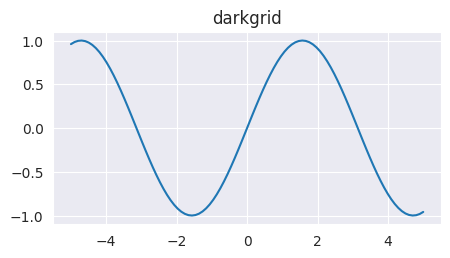

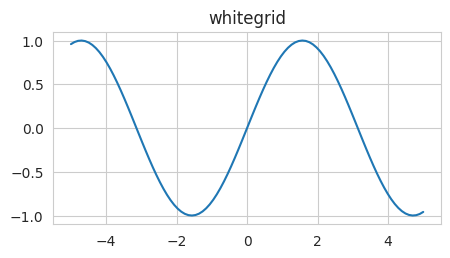

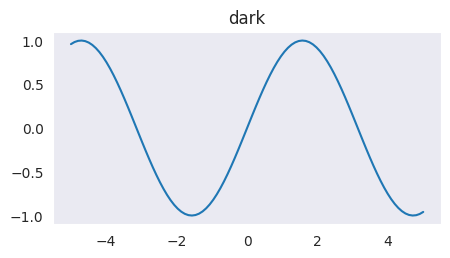

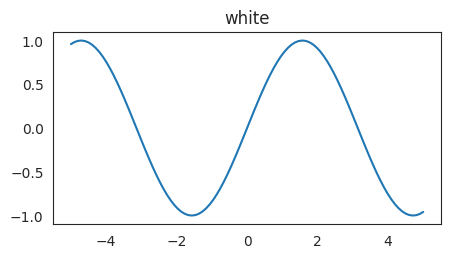

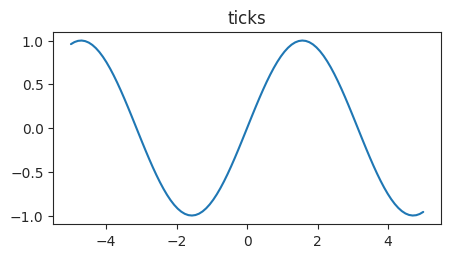

In [3]:
x = np.linspace(-5, 5, 100)
for style in ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']:
    sns.set_style(style)
    plt.figure(figsize=(5, 2.5))
    plt.plot(x, np.sin(x))
    plt.title(style)
    plt.show()

Более общий способ — `sns.set_theme()`: одним вызовом задаёт стиль, палитру, размер шрифта и «контекст» (`paper`, `notebook`, `talk`, `poster` — для статьи, ноутбука, презентации, постера).

In [4]:
sns.set_theme(style='darkgrid', context='notebook', palette='deep')

Регулируемые параметры текущего стиля:

In [5]:
sns.set_style?

In [6]:
sns.axes_style()

{'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': 'white',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

## 2. Визуализация парных взаимосвязей: `sns.lmplot`

`lmplot` рисует диаграмму рассеяния и поверх неё — линию регрессии с доверительным интервалом.

Загрузим датасет Ирисов Фишера — классический учебный набор: 150 цветков, 4 признака (длина и ширина чашелистика и лепестка), 3 вида.

In [7]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
names = iris.feature_names
target_names = iris.target_names

In [8]:
names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [9]:
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Соберём `DataFrame`. Названия видов получим одной операцией: массив `target_names` индексируется массивом номеров `y` — это NumPy-«причудливая индексация» (fancy indexing).

In [10]:
df = pd.DataFrame(X, columns=names)
df['target'] = y
df['target_names'] = target_names[y]
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


Рисуем график. `lmplot` — figure-level функция: она сама создаёт фигуру, поэтому размер задаём аргументом `height`, а не через `plt.figure()`:

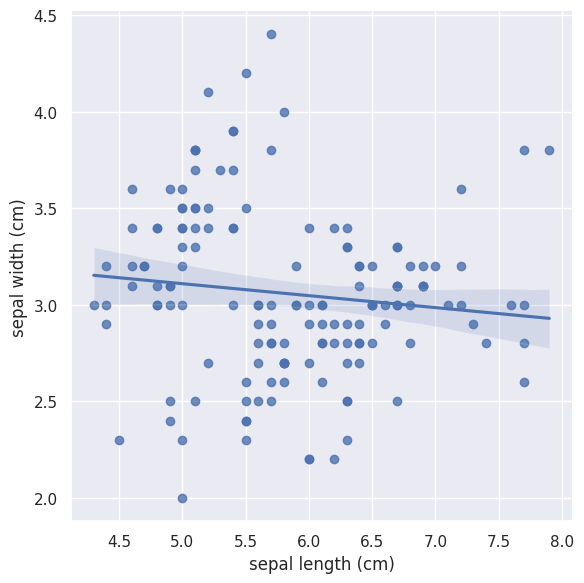

In [11]:
sns.lmplot(data=df, x='sepal length (cm)', y='sepal width (cm)', height=6)
plt.show()

Добавим цвет по виду — аргумент `hue`. Регрессия строится отдельно для каждой группы:

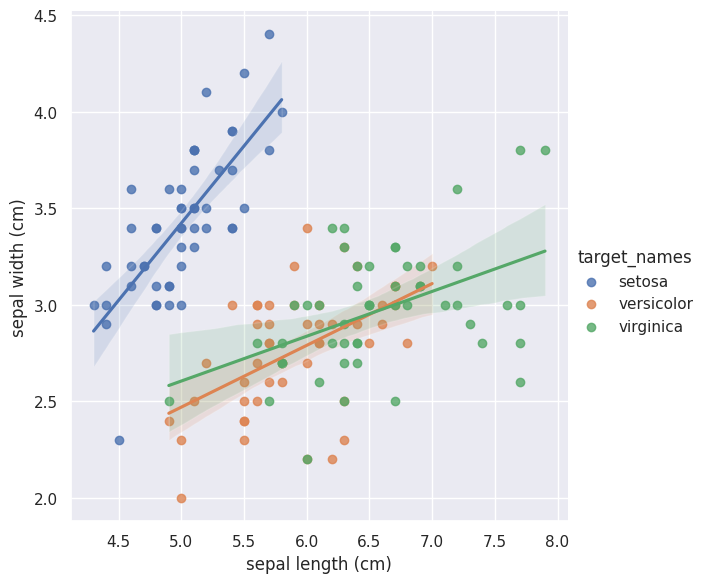

In [12]:
sns.lmplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='target_names', height=6)
plt.show()

`logx=True` — регрессия в логарифмических координатах по X:

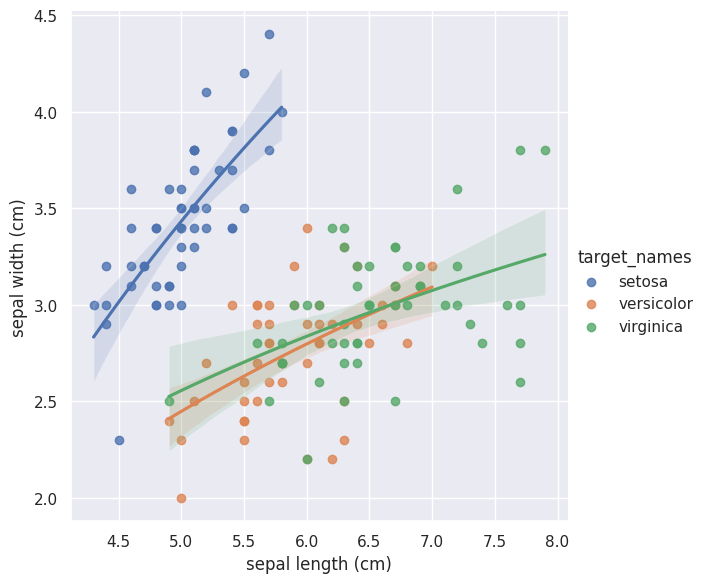

In [13]:
sns.lmplot(data=df, x='sepal length (cm)', y='sepal width (cm)',
           hue='target_names', logx=True, height=6)
plt.show()

## 3. Визуализация распределений признаков

### 3.1 `sns.boxplot` — «ящик с усами»

Показывает медиану, квартили (границы ящика), размах (усы) и выбросы (точки).

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [15]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Если передать `DataFrame` целиком (wide-формат), каждый числовой столбец станет отдельным ящиком:

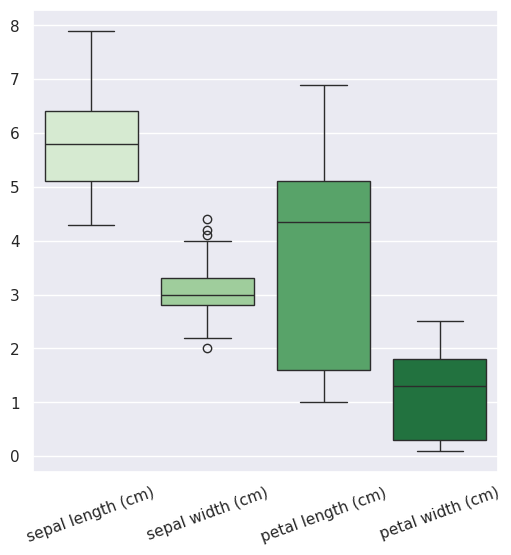

In [16]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df.drop(columns='target'), palette=sns.color_palette('Greens', n_colors=4))
plt.xticks(rotation=20)
plt.show()

Long-формат: один признак по X, категория по Y. В Seaborn 0.13+ палитру можно применять только вместе с `hue`; чтобы раскрасить категории без дублирования легенды, передаём `hue` тот же столбец и `legend=False`:

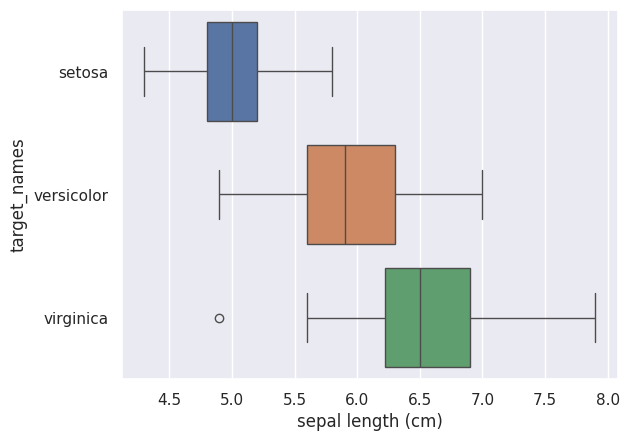

In [17]:
sns.boxplot(data=df, x='sepal length (cm)', y='target_names', hue='target_names', legend=False)
plt.show()

### 3.2 `sns.violinplot` — «скрипка»

То же, что boxplot, но вместо ящика — оценка плотности распределения. Видна форма: например, бимодальность, которую ящик скрывает.

In [18]:
sns.violinplot?

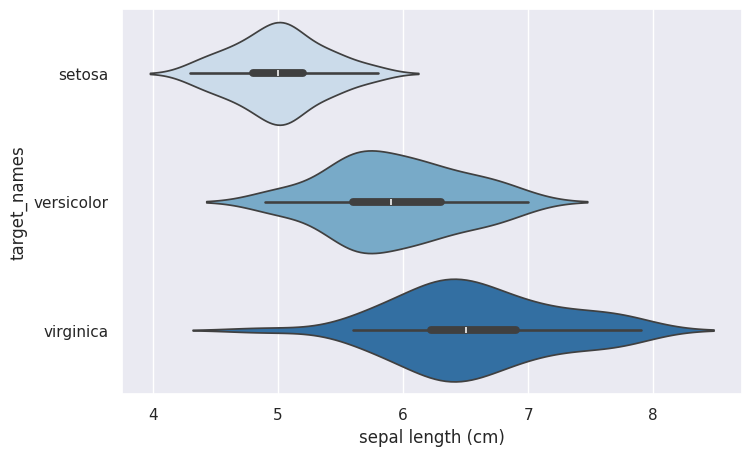

In [19]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='sepal length (cm)', y='target_names', hue='target_names',
               palette=sns.color_palette('Blues', n_colors=3), legend=False)
plt.show()

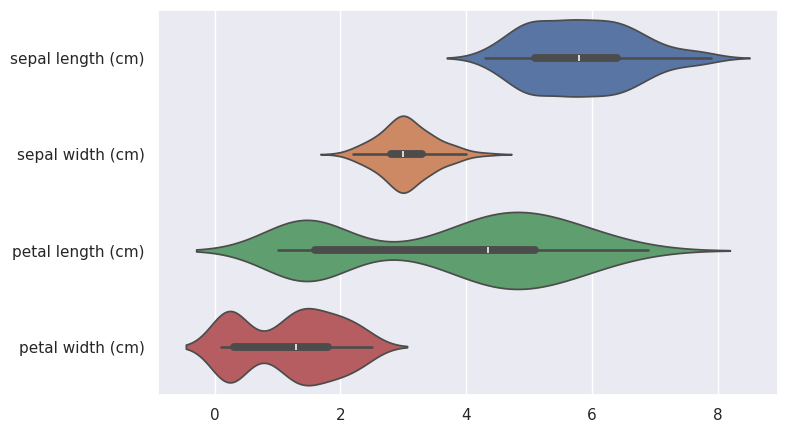

In [20]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df.drop(columns='target'), orient='h')
plt.show()

### 3.3 `sns.histplot` — гистограмма распределения

`kde=True` добавляет сглаженную оценку плотности.



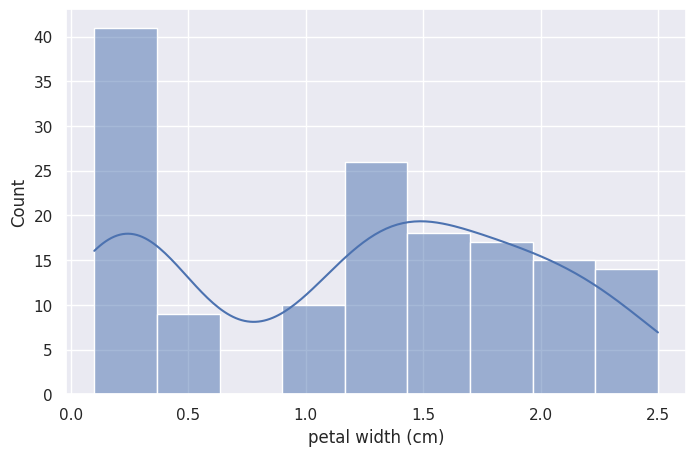

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='petal width (cm)', bins='auto', kde=True)
plt.show()

С `hue` распределения разных видов накладываются друг на друга:

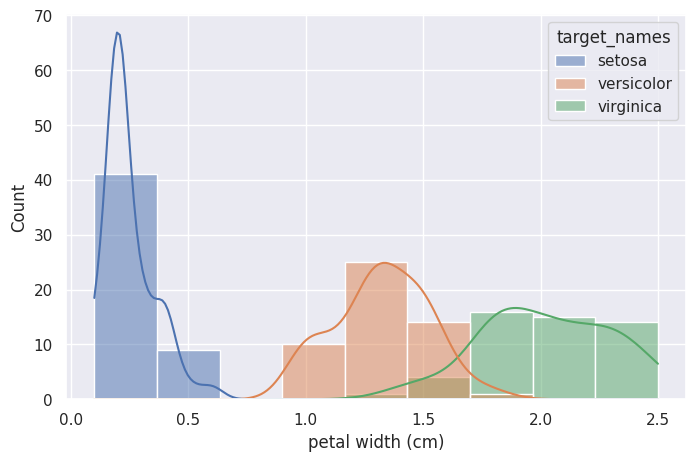

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='petal width (cm)', hue='target_names', kde=True)
plt.show()

In [23]:
sns.histplot?

## 4. Тепловая карта: `sns.heatmap`

Подходит для матрицы корреляций — или любой другой матрицы (расстояний, ошибок классификации и т.п.).

In [24]:
sns.heatmap?

Для корреляций нужна **расходящаяся** палитра: один цвет для отрицательных значений, другой — для положительных, нейтральный в нуле.

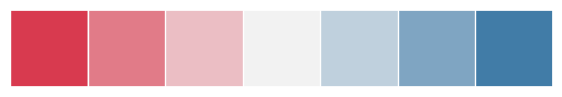

In [25]:
sns.palplot(sns.diverging_palette(8, 240, sep=20, n=7))

In [26]:
sns.diverging_palette?

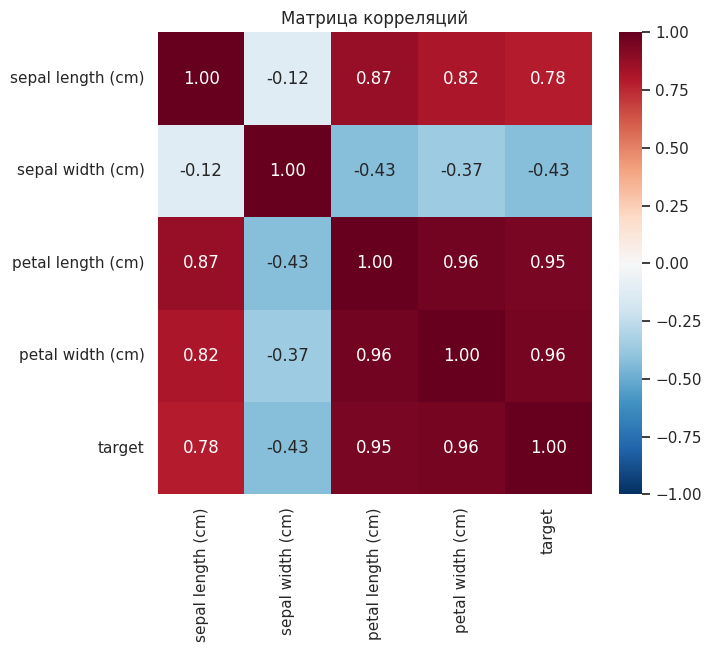

In [27]:
plt.figure(figsize=(7, 6))
corr = df.drop(columns='target_names').corr()
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

> `cmap` принимает название любой цветовой карты Matplotlib (`'RdBu_r'`, `'coolwarm'`, `'viridis'`...). Суффикс `_r` — обращённая (reversed) карта. `fmt='.2f'` — формат чисел в ячейках.

## 5. Подсчёт категорий: `sns.countplot`

Столбчатая диаграмма числа объектов в каждой категории. Обратите внимание на именованный аргумент `x=` — старая запись `sns.countplot(df.target_names)` в новых версиях не работает.

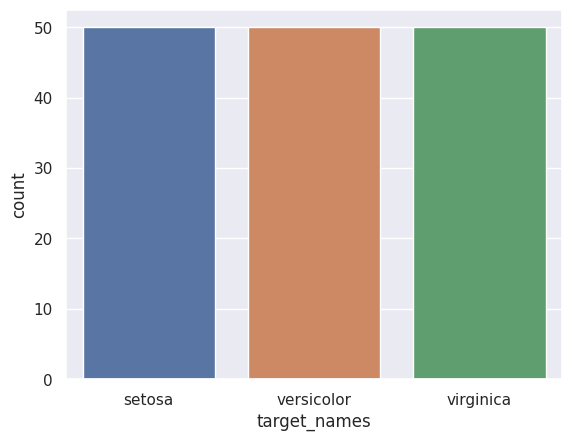

In [28]:
sns.countplot(data=df, x='target_names', hue='target_names', legend=False)
plt.show()

## 6. Совместные распределения

### `sns.jointplot`

Диаграмма рассеяния двух признаков плюс их одномерные распределения по краям.

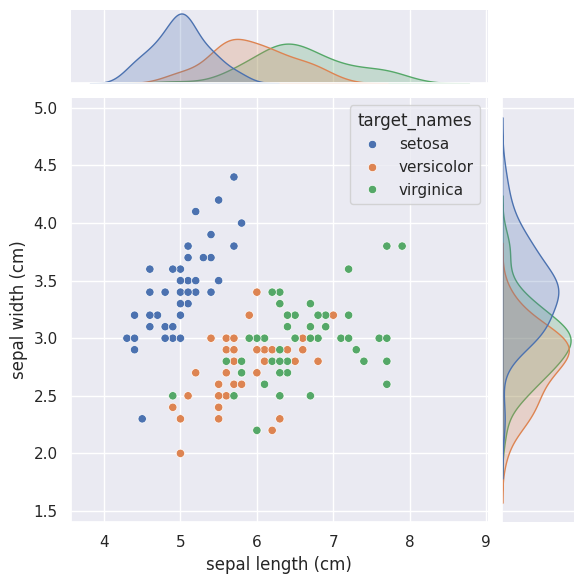

In [29]:
sns.jointplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='target_names')
plt.show()

Аргумент `kind` меняет тип центрального графика: `'scatter'`, `'kde'`, `'hist'`, `'hex'`, `'reg'`:

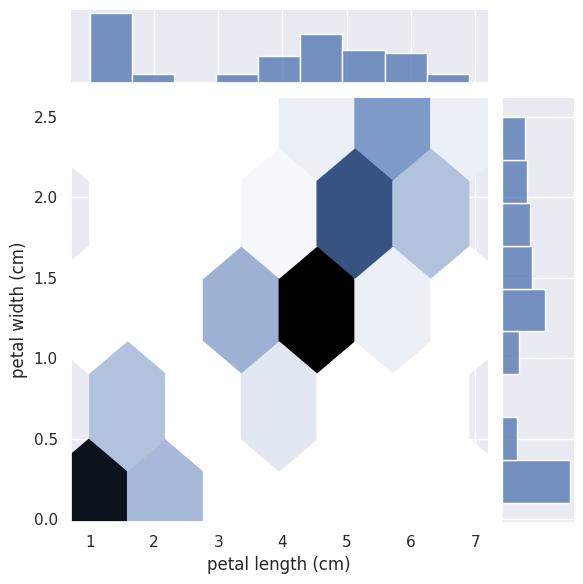

In [30]:
sns.jointplot(data=df, x='petal length (cm)', y='petal width (cm)', kind='hex')
plt.show()

### `sns.pairplot`

Все попарные диаграммы рассеяния сразу; на диагонали — распределение каждого признака. Самый быстрый способ «увидеть» небольшой датасет целиком.

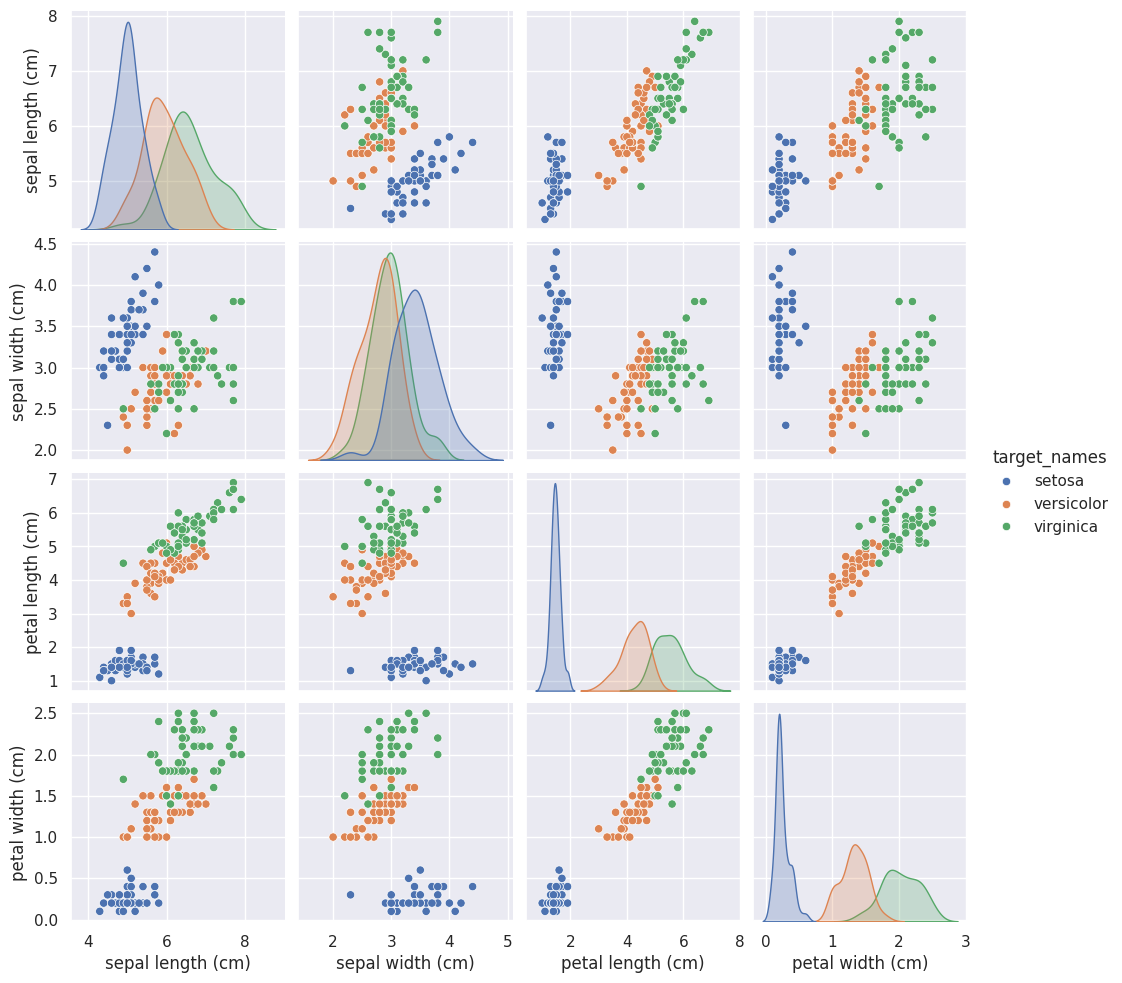

In [31]:
sns.pairplot(df.drop(columns='target'), hue='target_names')
plt.show()

## 7. Figure-level функции и встроенные датасеты

В Seaborn два уровня функций:

| Уровень | Примеры | Что делают |
|---|---|---|
| **axes-level** | `scatterplot`, `boxplot`, `histplot`, `heatmap` | рисуют на переданных осях (`ax=`), хорошо встраиваются в `plt.subplots` |
| **figure-level** | `relplot`, `catplot`, `displot`, `lmplot`, `jointplot`, `pairplot` | сами создают фигуру и умеют раскладывать данные на сетку панелей через `col=` / `row=` |

Figure-level функции — это по сути `axes-level + FacetGrid`. Например, `catplot(kind='box')` — это `boxplot`, разложенный по панелям.

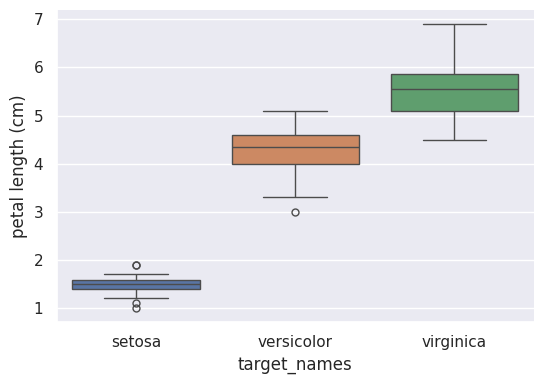

In [32]:
sns.catplot(data=df, x='target_names', y='petal length (cm)', hue='target_names',
            kind='box', legend=False, height=4, aspect=1.4)
plt.show()

`sns.load_dataset()` скачивает небольшие учебные датасеты с GitHub. Возьмём `tips` (чаевые в ресторане) и разложим график по дню недели:

In [33]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


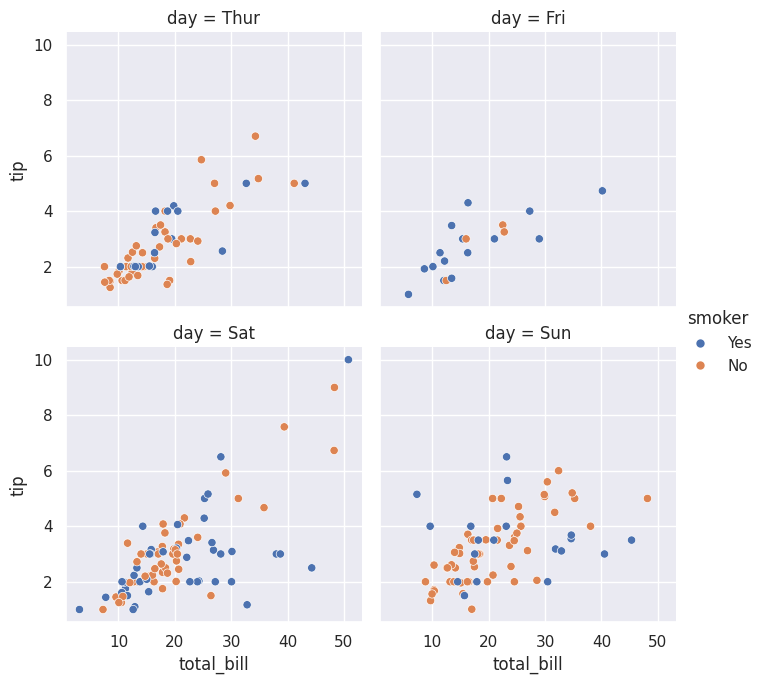

In [34]:
sns.relplot(data=tips, x='total_bill', y='tip', hue='smoker', col='day',
            col_wrap=2, height=3.5)
plt.show()

---

### ⚠️ Задачи для самостоятельной работы

1. На датасете `tips` постройте `boxplot` суммы чека (`total_bill`) по дням недели с разбивкой по `time` (обед/ужин) через `hue`.
2. Постройте тепловую карту корреляций числовых столбцов `tips`. Какая пара связана сильнее всего?
3. Через `sns.displot(..., kind='kde', col=...)` сравните распределение чаевых у курящих и некурящих.
4. Верните `sns.set_theme(context='talk')` и перерисуйте любой график — что изменилось? Когда такой режим полезен?

**Документация:** галерея примеров Seaborn — https://seaborn.pydata.org/examples/index.html